### 1.8.3. Ejemplo2 en Python: Predicción SO (regresión logística multinomial)

In [28]:
# import numpy as np
# import pandas as pd
# # Semilla para reproducibilidad
# np.random.seed(42)
# # Número de muestras
# n = 5000
# # -----------------------------
# # 1. Generación de variables numéricas
# # -----------------------------
# # Ancho de pantalla (px)
# # Windows: muy variado, macOS: alto, Linux: medio
# ancho_windows = np.random.normal(1366, 200, int(n*0.6))
# ancho_mac = np.random.normal(2560, 150, int(n*0.25))
# ancho_linux = np.random.normal(1920, 180, int(n*0.15))
# ancho_pantalla = np.concatenate([ancho_windows, ancho_mac, ancho_linux])
# # Alto de pantalla (px)
# alto_windows = np.random.normal(768, 120, int(n*0.6))
# alto_mac = np.random.normal(1600, 100, int(n*0.25))
# alto_linux = np.random.normal(1080, 130, int(n*0.15))
# alto_pantalla = np.concatenate([alto_windows, alto_mac, alto_linux])
# # Velocidad de scroll (px/s)
# scroll_windows = np.random.normal(800, 150, int(n*0.6))
# scroll_mac = np.random.normal(1200, 200, int(n*0.25))
# scroll_linux = np.random.normal(900, 180, int(n*0.15))
# velocidad_scroll = np.concatenate([scroll_windows, scroll_mac, scroll_linux])
# # Tiempo de carga (ms)
# carga_windows = np.random.normal(900, 150, int(n*0.6))
# carga_mac = np.random.normal(700, 120, int(n*0.25))
# carga_linux = np.random.normal(850, 140, int(n*0.15))
# tiempo_carga_ms = np.concatenate([carga_windows, carga_mac, carga_linux])
# # -----------------------------
# # 2. Variable objetivo (SO)
# # -----------------------------
# # 0 = Windows, 1 = Macintosh, 2 = Linux
# so = np.array(
# [0]*int(n*0.6) +
# [1]*int(n*0.25) +
# [2]*int(n*0.15)
# )
# # -----------------------------
# # 3. Crear DataFrame
# # -----------------------------
# data = pd.DataFrame({
# 'ancho_pantalla': ancho_pantalla,
# 'alto_pantalla': alto_pantalla,
# 'velocidad_scroll': velocidad_scroll,
# 'tiempo_carga_ms': tiempo_carga_ms,
# 'so': so
# })
# # -----------------------------
# # 4. Exportar a CSV
# # -----------------------------
# data.to_csv("SO.csv", index=False)
# print("Dataset generado con éxito. Tamaño:", data.shape)
# print(data.head())

1. Preparación del entorno

In [29]:
# Librerías para manejo de datos
import pandas as pd
import numpy as np
# Librerías para machine learning
from sklearn import linear_model, model_selection
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Visualización
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline

In [30]:
# CARGA DEL DATASET
data = pd.read_csv("SO.csv")
# Mostrar primeras filas
data.head()

,ancho_pantalla,alto_pantalla,velocidad_scroll,tiempo_carga_ms,so
0,1465.342831,717.148838,698.225790,878.486518,0
1,1338.347140,713.590307,754.175081,895.101614,0
2,1495.537708,552.522819,710.392841,909.644232,0
3,1670.605971,728.389177,816.562707,1042.029219,0
4,1319.169325,855.939490,979.576780,787.917404,0


3. Exploración inicial del dataset

(5000, 5)
       ancho_pantalla  alto_pantalla  velocidad_scroll  tiempo_carga_ms  \
count     5000.000000    5000.000000       5000.000000      5000.000000   
mean      1749.247583    1021.527426        917.435935       844.878648   
std        534.385886     371.138935        242.270665       165.500281   
min        717.746532     325.396165        293.663135       299.691814   
25%       1328.923902     737.346419        748.629587       727.898968   
50%       1553.585394     880.600296        875.819592       844.828472   
75%       2227.964708    1357.028562       1052.951843       959.858369   
max       3046.463945    1937.738292       1885.782096      1571.862638   

                so  
count  5000.000000  
mean      0.550000  
std       0.740006  
min       0.000000  
25%       0.000000  
50%       0.000000  
75%       1.000000  
max       2.000000  
so
0    3000
1    1250
2     750
Name: count, dtype: int64


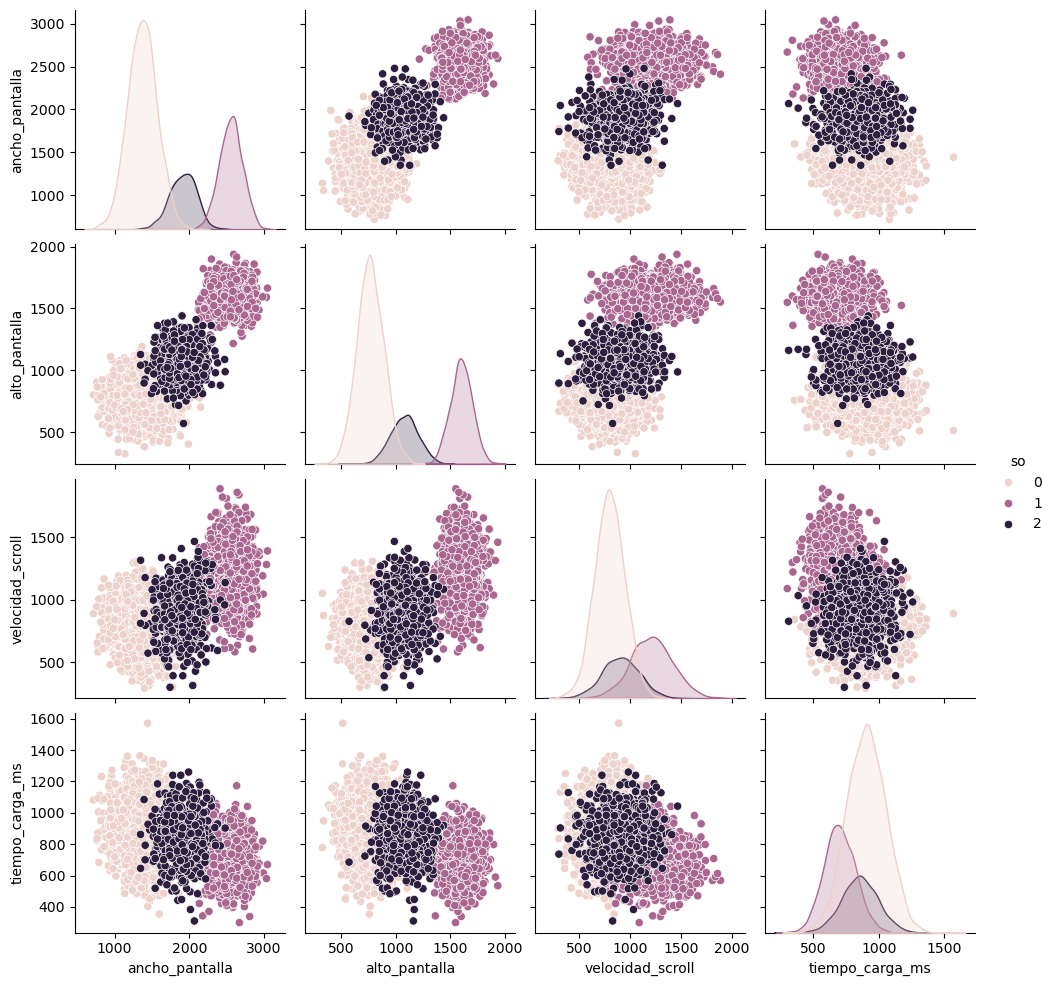

In [31]:
# EXPLORACIÓN INICIAL
print(data.shape)
print(data.describe())
print(data['so'].value_counts())
sb.pairplot(data, hue='so')
plt.show()

4. División Train/Test

In [32]:
# DIVISIÓN TRAIN/TEST
X = data[['ancho_pantalla', 'alto_pantalla', 'velocidad_scroll', 'tiempo_carga_ms']]
y = data['so']
X_train, X_test, y_train, y_test = model_selection.train_test_split(
X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((4000, 4), (1000, 4))

5. Entrenamiento del modelo (Regresión Logística Multinomial)

In [ ]:
# ESCALADO DE VARIABLES
# Pepe: Ajustamos los valores de todas las variables a la misma escala para poder comparar unas con otras.
#       A esto se le llama un escalado de los valores.
#       Si los valores de las variables siguen una distribución próxima a la normal (con forma de campana) podemos compararlas entre ellas.
# 1º Ver cuáles tienen forma de campana
# 2º Si tienen foma de campana podemos usarlas para entrenar el modelo
# 3º Entonces hay que tipificarlas/escalarlas para que estén dentro de la misma escala (donde la media debía ser 0 y la desviación 1)
# -> N(0,1) donde 0 es la media y 1 es la desviación, los valores de X estarán comprendidos entre -3 y 3
#           X = (x-media)/desviación
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# ENTRENAMIENTO DEL MODELO MULTINOMIAL (corregido)
modelo = linear_model.LogisticRegression(
solver='lbfgs',
max_iter=1000
)
modelo.fit(X_train_scaled, y_train)
print("Coeficientes del modelo:")
print(modelo.coef_)
# Pepe: Cuánto más grande el coeficiente (en valor absoluto) más influye sobre la estimación, ya que es la Bn que se multiplica por Xn
print("\nIntercept:")
print(modelo.intercept_)

Coeficientes del modelo:
[[-5.06226328 -5.27659908 -0.74242871  0.60764299]
 [ 4.30687823  5.13599462  0.83305825 -0.74368374]
 [ 0.75538505  0.14060446 -0.09062954  0.13604075]]

Intercept:
[ 1.68694288 -4.98072312  3.29378024]


6. Evaluación completa del modelo

In [34]:
# EVALUACIÓN COMPLETA DEL MODELO
# 1. Predicciones usando los datos escalados
y_pred = modelo.predict(X_test_scaled)
# 2. Accuracy
print("Accuracy del modelo:", accuracy_score(y_test, y_pred))
# 3. Matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))
# 4. Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Accuracy del modelo: 0.98

Matriz de confusión:
[[592   0   6]
 [  0 252   0]
 [ 14   0 136]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       598
           1       1.00      1.00      1.00       252
           2       0.96      0.91      0.93       150

    accuracy                           0.98      1000
   macro avg       0.98      0.97      0.97      1000
weighted avg       0.98      0.98      0.98      1000



7. Visualización de la frontera de decisión (solo 2 variables)

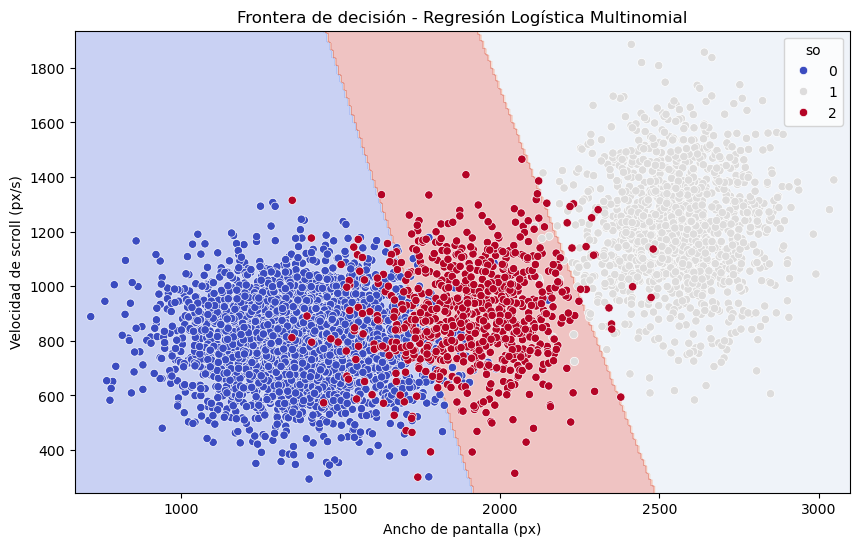

In [35]:
#🎨 VISUALIZACIÓN DE LA FRONTERA DE DECISIÓN (2 variables)
from sklearn.preprocessing import StandardScaler
# Seleccionamos solo dos variables para poder graficar
X2 = data[['ancho_pantalla', 'velocidad_scroll']]
y2 = data['so']
# Escalado de estas dos variables
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)
# Entrenamos un modelo SOLO con estas dos variables
modelo2 = linear_model.LogisticRegression(
solver='lbfgs',
max_iter=1000
)
modelo2.fit(X2_scaled, y2)
# Crear malla de puntos para graficar la frontera
x_min, x_max = X2['ancho_pantalla'].min() - 50, X2['ancho_pantalla'].max() + 50
y_min, y_max = X2['velocidad_scroll'].min() - 50, X2['velocidad_scroll'].max() + 50
xx, yy = np.meshgrid(
np.linspace(x_min, x_max, 300),
np.linspace(y_min, y_max, 300)
)
# Convertimos la malla en DataFrame
grid = pd.DataFrame({
'ancho_pantalla': xx.ravel(),
'velocidad_scroll': yy.ravel()
})
# Escalamos la malla igual que los datos reales
grid_scaled = scaler2.transform(grid)
# Predicción sobre la malla
Z = modelo2.predict(grid_scaled)
Z = Z.reshape(xx.shape)
# Gráfico
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
# Puntos reales
sb.scatterplot(
data=data,
x='ancho_pantalla',
y='velocidad_scroll',
hue='so',
palette='coolwarm'
)
plt.title("Frontera de decisión - Regresión Logística Multinomial")
plt.xlabel("Ancho de pantalla (px)")
plt.ylabel("Velocidad de scroll (px/s)")
plt.show()

8. Interpretación del modelo

In [36]:
# INTERPRETACIÓN DE COEFICIENTES
coef_df = pd.DataFrame(modelo.coef_, columns=X.columns)
coef_df['Clase (SO)'] = ['Windows (0)', 'Macintosh (1)', 'Linux (2)']
coef_df

,ancho_pantalla,alto_pantalla,velocidad_scroll,tiempo_carga_ms,Clase (SO)
0,-5.062263,-5.276599,-0.742429,0.607643,Windows (0)
1,4.306878,5.135995,0.833058,-0.743684,Macintosh (1)
2,0.755385,0.140604,-0.090630,0.136041,Linux (2)
